# EDA 10 — Two Bureau answers to "how sure are we?": SAIPE vs ACS for NJ county income & poverty

**Question (Phase 2 scope, HANDOFF next-work #3; research questions Q3–Q4):** The Census Bureau publishes uncertainty for the *same* income and poverty quantities in two different products with two different styles — ACS 5-year direct survey estimates with a **margin of error**, and SAIPE model-based estimates with a **90% confidence interval + MOE**. For New Jersey's 21 counties: when do the two products agree, whose published interval is tighter, and what does each style actually communicate to a non-statistician?

**Plain-English setup.** The ACS number for a county is a *direct* estimate: it is whatever the sampled households in that county said, pooled over five years, and its MOE measures sampling wobble. The SAIPE number is a *model-based* estimate: a statistical model blends one year of ACS data with IRS tax records, SNAP enrollment, and population estimates, and its interval measures model error (see [`docs/glossary.md`](../docs/glossary.md): *SAIPE*, *confidence interval*). Both are official, both are defensible, and they answer subtly different questions — which is exactly why the comparison teaches us how uncertainty should be communicated (Q4) and which published metric fits which use (Q3).

**Measurement facts that shape this notebook** (verified live against the API, 2026-08-01, and re-asserted below):
- **Same year label ≠ same window.** SAIPE year Y is a single-year estimate; ACS 5-year vintage Y averages years Y−4..Y (vintage 2024 is centered near 2022). Every same-label comparison here is a comparison of *communication styles for the same labeled year*, never a claim that either number is "wrong."
- **Both products publish at 90% confidence**, so their half-widths are directly comparable. SAIPE's published MOE equals half its published CI width exactly (asserted on every row).
- **The ACS poverty rate must be derived** (below-poverty count ÷ poverty universe), and its MOE needs the handbook **proportion formula** — the universe is not total population, and root-sum-of-squares would be the wrong combination rule for a subset ratio ([`analysis/acs.py::proportion_moe`](../analysis/acs.py), ACS handbook Ch. 8).

**Data.** SAIPE: `python ingestion/pull_saipe_nj.py` (21 counties × 2019–2024). ACS: `python ingestion/pull_acs_income_county_nj.py` (same counties, vintages 2019–2024, with MOEs). Shared formulas: [`analysis/acs.py`](../analysis/acs.py).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import acs

RAW = REPO_ROOT / "data" / "raw"
PROCESSED = REPO_ROOT / "data" / "processed"
YEARS = [str(y) for y in range(2019, 2025)]
EXPECTED_ROWS = 21 * len(YEARS)

def load_parquet(name: str, regen: str) -> pd.DataFrame:
    path = RAW / name
    if not path.exists():
        raise FileNotFoundError(f"{path} -- regenerate with: python ingestion/{regen}")
    return pd.read_parquet(path)

saipe = load_parquet("saipe_nj_county_2019_2024.parquet", "pull_saipe_nj.py")
acs_cty = load_parquet("acs5_nj_county_income_2019_2024.parquet", "pull_acs_income_county_nj.py")

# SAIPE arrives as raw API strings (raw-stays-raw convention) -- coerce here.
saipe_num_cols = [c for c in saipe.columns if c.startswith("SAE")]
saipe[saipe_num_cols] = saipe[saipe_num_cols].apply(pd.to_numeric, errors="coerce")
saipe["YEAR"] = saipe["YEAR"].astype(str)
acs_cty["VINTAGE"] = acs_cty["VINTAGE"].astype(str)

print(f"SAIPE rows: {len(saipe)}   ACS rows: {len(acs_cty)}")

SAIPE rows: 126   ACS rows: 126


## 1. Data quality before analysis

Row counts, a 1:1 join on county × year label, and re-assertions of the two facts everything downstream leans on: SAIPE's MOE ≡ half its CI width, and the ACS below-poverty count never exceeds its universe. The ACS poverty rate and its proportion-formula MOE are derived here.


In [2]:
assert len(saipe) == EXPECTED_ROWS, f"SAIPE: expected {EXPECTED_ROWS} rows (21 counties x 6 years), got {len(saipe)}"
assert len(acs_cty) == EXPECTED_ROWS, f"ACS: expected {EXPECTED_ROWS} rows, got {len(acs_cty)}"

# SAIPE identity: published MOE == half the published 90% CI width, every row.
for stem, tol in [("SAEMHI", 0.51), ("SAEPOVRTALL", 0.06)]:
    half = (saipe[f"{stem}_UB90"] - saipe[f"{stem}_LB90"]) / 2
    worst = (saipe[f"{stem}_MOE"] - half).abs().max()
    assert worst <= tol, f"{stem}: published MOE should equal half the CI width (max diff {worst})"
print("SAIPE MOE == (UB90 - LB90)/2 on all rows, both measures")

assert (acs_cty["B17001_002E"] <= acs_cty["B17001_001E"]).all(), \
    "ACS: below-poverty count should never exceed its universe"

# Derived ACS poverty rate (%) with the handbook proportion MOE.
acs_cty["pov_rate"] = 100 * acs_cty["B17001_002E"] / acs_cty["B17001_001E"]
acs_cty["pov_rate_moe"] = 100 * acs.proportion_moe(
    acs_cty["B17001_002E"], acs_cty["B17001_002M"],
    acs_cty["B17001_001E"], acs_cty["B17001_001M"],
)
assert acs_cty["pov_rate"].between(0, 100).all(), "derived poverty rate should be a percentage"
assert acs_cty["pov_rate_moe"].notna().all() and (acs_cty["pov_rate_moe"] > 0).all(), \
    "every county-vintage should get a positive derived rate MOE"

# 1:1 join on county FIPS x year label.
panel = saipe.merge(
    acs_cty, left_on=["county", "YEAR"], right_on=["COUNTY", "VINTAGE"],
    how="outer", indicator=True, suffixes=("_saipe", "_acs"),
)
assert (panel["_merge"] == "both").all(), "county x year join should be 1:1 with no orphans"
assert panel["county"].nunique() == 21, "should cover all 21 NJ counties"
panel["short_name"] = panel["NAME_saipe"].str.replace(" County", "", regex=False)
print(f"Joined panel: {len(panel)} county-years, {panel['county'].nunique()} counties, {panel['YEAR'].nunique()} years")

SAIPE MOE == (UB90 - LB90)/2 on all rows, both measures
Joined panel: 126 county-years, 21 counties, 6 years


## 2. Same label, different answers — the point estimates

For each year label, how far apart are the two products' answers? Reported as SAIPE minus ACS, in percent of the ACS value. **Framing guard:** a gap here is *informative divergence between two defensible answers with different windows* — SAIPE's single year vs the ACS's five-year average — not an error in either. During years of rising incomes the single-year product should sit above the trailing average.


In [3]:
panel["inc_diff_pct"] = 100 * (panel["SAEMHI_PT"] - panel["B19013_001E"]) / panel["B19013_001E"]
panel["rate_diff_pp"] = panel["SAEPOVRTALL_PT"] - panel["pov_rate"]

by_year = panel.groupby("YEAR").agg(
    med_income_diff_pct=("inc_diff_pct", "median"),
    med_rate_diff_pp=("rate_diff_pp", "median"),
    counties_saipe_higher_income=("inc_diff_pct", lambda s: int((s > 0).sum())),
).round(2)
assert by_year["med_income_diff_pct"].abs().max() <= 2.5, \
    "same-label income answers should agree within a few percent of each other"
assert by_year["med_rate_diff_pp"].abs().max() <= 0.6, \
    "same-label poverty rates should agree within about half a point"
print("SAIPE minus ACS, by year label (income: % of ACS value; poverty rate: percentage points)")
by_year

SAIPE minus ACS, by year label (income: % of ACS value; poverty rate: percentage points)


,med_income_diff_pct,med_rate_diff_pp,counties_saipe_higher_income
YEAR,,,
2019,1.95,-0.52,17
2020,1.07,-0.09,13
2021,-1.17,0.52,6
2022,-0.70,-0.01,10
2023,-1.74,0.03,3
2024,-0.68,-0.28,8


**What the table says.** The two products' same-label answers agree within a couple of percent — median income gaps run −1.7% to +2.0%, poverty-rate gaps within ±0.5 points — and the *sign* of the gap is time-structured: SAIPE sat above the ACS in 2019–2020 (17 and 13 of 21 counties), then mostly below it from 2021 on (as the ACS's five-year window caught up with the strong recent income growth). That is the window mismatch made visible: a single-year product leads a trailing five-year average on the way up and re-crosses it after. Two defensible answers to differently-timed questions — which is why neither gap column reads as "error."


## 3. The headline: whose published interval is tighter?

Both products publish at 90% confidence, so **relative half-width** — the published MOE as a share of the estimate — puts them on one comparable axis (for income this is `MOE/estimate`; dividing by 1.645 would turn it into a CV, the same ordering either way). The ratio SAIPE-width ÷ ACS-width says which style gives the *narrower* published interval for the same labeled county-year.


In [4]:
panel["inc_relwidth_acs"] = panel["B19013_001M"] / panel["B19013_001E"]
panel["inc_relwidth_saipe"] = panel["SAEMHI_MOE"] / panel["SAEMHI_PT"]
panel["rate_relwidth_acs"] = panel["pov_rate_moe"] / panel["pov_rate"]
panel["rate_relwidth_saipe"] = panel["SAEPOVRTALL_MOE"] / panel["SAEPOVRTALL_PT"]
panel["inc_width_ratio"] = panel["inc_relwidth_saipe"] / panel["inc_relwidth_acs"]
panel["rate_width_ratio"] = panel["rate_relwidth_saipe"] / panel["rate_relwidth_acs"]

summary = pd.DataFrame({
    "median relative half-width": {
        "income, ACS": panel["inc_relwidth_acs"].median(),
        "income, SAIPE": panel["inc_relwidth_saipe"].median(),
        "poverty rate, ACS": panel["rate_relwidth_acs"].median(),
        "poverty rate, SAIPE": panel["rate_relwidth_saipe"].median(),
    }
}).round(4)
share_saipe_wider_inc = float((panel["inc_width_ratio"] > 1).mean())
share_saipe_wider_rate = float((panel["rate_width_ratio"] > 1).mean())
print(f"county-years where the SAIPE interval is WIDER than the ACS interval: "
      f"income {share_saipe_wider_inc:.0%}, poverty rate {share_saipe_wider_rate:.0%}")
print(f"median width ratio (SAIPE/ACS): income {panel['inc_width_ratio'].median():.2f}, "
      f"rate {panel['rate_width_ratio'].median():.2f}")

assert share_saipe_wider_inc >= 0.95 and share_saipe_wider_rate >= 0.95, \
    "headline claim: the SAIPE interval should be wider in >=95% of county-years"
assert 1.5 <= panel["inc_width_ratio"].median() <= 2.5 and 1.5 <= panel["rate_width_ratio"].median() <= 2.5, \
    "headline claim: SAIPE runs about twice the ACS relative width at NJ county scale"

# Size relationship, descriptive only (21 counties is far too few for anything stronger).
rho = panel.loc[panel.YEAR == "2024"].pipe(
    lambda d: d[["SAEPOVU_ALL", "inc_width_ratio"]].corr(method="spearman").iloc[0, 1])
print(f"Spearman(universe size, income width ratio), 2024 only, descriptive: {rho:.2f}")
summary

county-years where the SAIPE interval is WIDER than the ACS interval: income 99%, poverty rate 100%
median width ratio (SAIPE/ACS): income 2.01, rate 2.02
Spearman(universe size, income width ratio), 2024 only, descriptive: -0.02


,median relative half-width
"income, ACS",0.0215
"income, SAIPE",0.0434
"poverty rate, ACS",0.0725
"poverty rate, SAIPE",0.1477


**What the table says.** The naive expectation — "the model-based product should have the tighter interval" — is *backwards* at New Jersey county scale. SAIPE's published interval is wider in **99% (income) and 100% (poverty rate)** of county-years, at a median of about **2× the ACS's relative width** for both measures (income 4.3% vs 2.2% of the estimate; poverty rate 14.8% vs 7.3%), and the ratio is unrelated to county size within the state (Spearman ≈ −0.02 — all 21 NJ counties are large by national standards, so SAIPE's famous small-area advantage never gets to show itself here).

The right reading is **not** "ACS wins." The ACS buys its narrow interval by averaging five years of data — its answer is older, centered near 2022. SAIPE buys single-year currency and pays for it in width. The two intervals are pricing *different questions*, and narrower is not better — a planner who needs this year's number should prefer the honest wide interval; one tracking a stable average should prefer the tight stale one. That distinction is fitness-for-use in a single comparison, and it is exactly the kind of guidance our tool's verdicts must encode.


## 4. Do the intervals contain each other's answers?

A descriptive consistency check — **not** a hypothesis test (the two products target different windows, so containment is not required even if both are perfect): how often does each product's point estimate fall inside the other's published 90% interval for the same labeled year?


In [5]:
contain = pd.DataFrame({
    "ACS point inside SAIPE 90% CI": {
        "income": float(panel["B19013_001E"].between(panel["SAEMHI_LB90"], panel["SAEMHI_UB90"]).mean()),
        "poverty rate": float(panel["pov_rate"].between(panel["SAEPOVRTALL_LB90"], panel["SAEPOVRTALL_UB90"]).mean()),
    },
    "SAIPE point inside ACS interval": {
        "income": float((abs(panel["SAEMHI_PT"] - panel["B19013_001E"]) <= panel["B19013_001M"]).mean()),
        "poverty rate": float((abs(panel["SAEPOVRTALL_PT"] - panel["pov_rate"]) <= panel["pov_rate_moe"]).mean()),
    },
}).round(2)
assert (contain.iloc[:, 0] >= contain.iloc[:, 1]).all(), \
    "the wider SAIPE interval should contain the ACS answer more often than the reverse"
contain

,ACS point inside SAIPE 90% CI,SAIPE point inside ACS interval
income,0.75,0.51
poverty rate,0.86,0.61


**What the table says.** The asymmetry is the width story again: the wide SAIPE interval usually contains the ACS answer (75% for income, 86% for the rate), while the narrow ACS interval returns the favor only about half the time (51% / 61%). Since the two products target different windows, containment was never owed — but the pattern confirms the intervals differ mainly in width, not in where they think the truth sits.


## 5. Same year label, different windows — the trajectory chart

Bergen (NJ's most populous county) and Salem (its least) over 2019–2024: SAIPE's single-year points with their CIs against the ACS's overlapping five-year averages with their MOEs. This is the teaching picture for the window mismatch — the two series answer "what year?" differently, and the vertical gap between them is mostly *that*, not disagreement about the county.


Chart saved to data\processed\eda10_window_mismatch.png (local-only, regenerable)


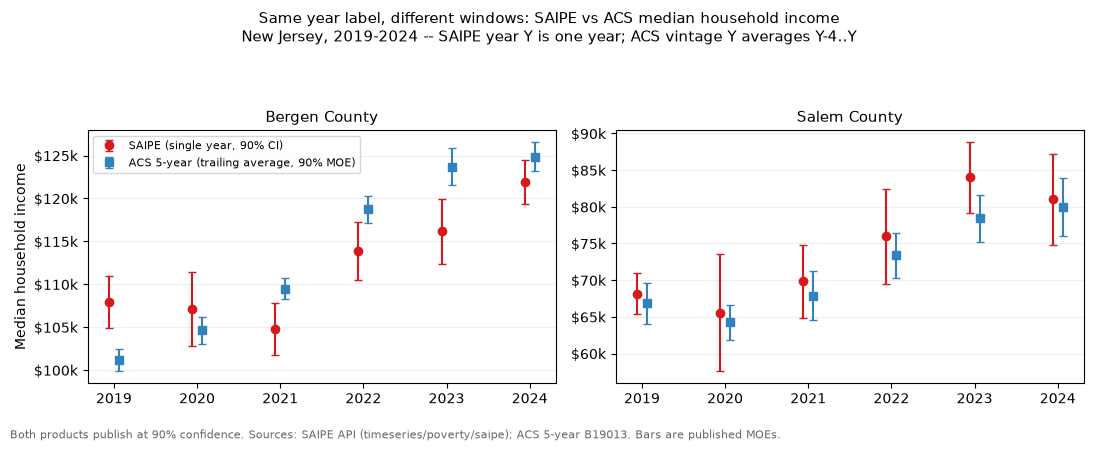

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
for ax, fips, label in [(axes[0], "003", "Bergen County"), (axes[1], "033", "Salem County")]:
    d = panel[panel["county"] == fips].sort_values("YEAR")
    x = d["YEAR"].astype(int)
    ax.errorbar(x - 0.06, d["SAEMHI_PT"], yerr=d["SAEMHI_MOE"], fmt="o", color="#d7191c",
                capsize=3, label="SAIPE (single year, 90% CI)")
    ax.errorbar(x + 0.06, d["B19013_001E"], yerr=d["B19013_001M"], fmt="s", color="#3182bd",
                capsize=3, label="ACS 5-year (trailing average, 90% MOE)")
    ax.set_title(label, fontsize=11)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(lambda v, _: f"${v/1000:,.0f}k")
axes[0].set_ylabel("Median household income")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Same year label, different windows: SAIPE vs ACS median household income\n"
             "New Jersey, 2019-2024 -- SAIPE year Y is one year; ACS vintage Y averages Y-4..Y",
             fontsize=11)
fig.text(0.01, -0.04, "Both products publish at 90% confidence. Sources: SAIPE API (timeseries/poverty/saipe); "
         "ACS 5-year B19013. Bars are published MOEs.", fontsize=8, color="#666666")
fig.tight_layout(rect=(0, 0, 1, 0.90))
out = PROCESSED / "eda10_window_mismatch.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

**Reading the chart.** Bergen: both series climb together, with the red single-year points leading the blue trailing average through the 2021–2023 income run-up — the vertical gaps are timing, not disagreement. Salem: the same picture with visibly wider bars from *both* products — one-nineteenth of Bergen's population means more humility from every method. Note the red bars dwarf the blue ones in both panels: that is the 2× width headline, drawn.


## 6. Four ways to say the same number

The communication question in miniature: Salem County's 2024 median household income, presented the four ways the Bureau's products (and our tool) could present it. Only the reader can judge which they could act on — that judgment is the dashboard's design brief. (CV tiers cited descriptively per project decision #8: 0.12 / 0.30 / 0.40 are ESRI/NCHS conventions, not our thresholds.)


In [7]:
salem = panel[(panel["county"] == "033") & (panel["YEAR"] == "2024")].iloc[0]
est, moe = salem["B19013_001E"], salem["B19013_001M"]
cv_val = float(acs.cv(pd.Series([est]), pd.Series([moe])).iloc[0])
tier = "high reliability (CV <= 0.12, ESRI convention)" if cv_val <= 0.12 else "medium" if cv_val <= 0.30 else "low"
presentations = pd.DataFrame({
    "presentation": ["bare point (data.census.gov default view)",
                      "point +/- MOE (ACS publication style)",
                      "90% confidence interval (SAIPE publication style)",
                      "CV + plain-language tier (our tool's direction)"],
    "Salem County 2024, median HH income": [
        f"${est:,.0f}",
        f"${est:,.0f} +/- ${moe:,.0f}",
        f"${salem['SAEMHI_LB90']:,.0f} to ${salem['SAEMHI_UB90']:,.0f} (SAIPE: ${salem['SAEMHI_PT']:,.0f})",
        f"CV {cv_val:.3f} -> {tier}",
    ],
})
presentations.style.hide(axis="index")

presentation,"Salem County 2024, median HH income"
bare point (data.census.gov default view),"$79,960"
point +/- MOE (ACS publication style),"$79,960 +/- $3,982"
90% confidence interval (SAIPE publication style),"$74,753 to $87,265 (SAIPE: $81,009)"
CV + plain-language tier (our tool's direction),"CV 0.030 -> high reliability (CV <= 0.12, ESRI convention)"


**What the table says.** Four honest presentations of one number, four different felt precisions. The bare point (the default view a planner actually encounters) communicates the least and implies the most. The MOE and CI forms are honest but demand arithmetic and statistical context from the reader. The CV-plus-tier line is the only one a non-statistician can act on as written — and writing that line for every estimate is precisely the dashboard's design brief.


## 7. The chart

All 21 counties, 2024, both measures: the ACS interval and the SAIPE interval side by side, counties sorted by poverty-universe size. One picture of the Bureau's two published uncertainty styles for the same labeled year.


Chart saved to data\processed\eda10_saipe_vs_acs_intervals.png (local-only, regenerable)


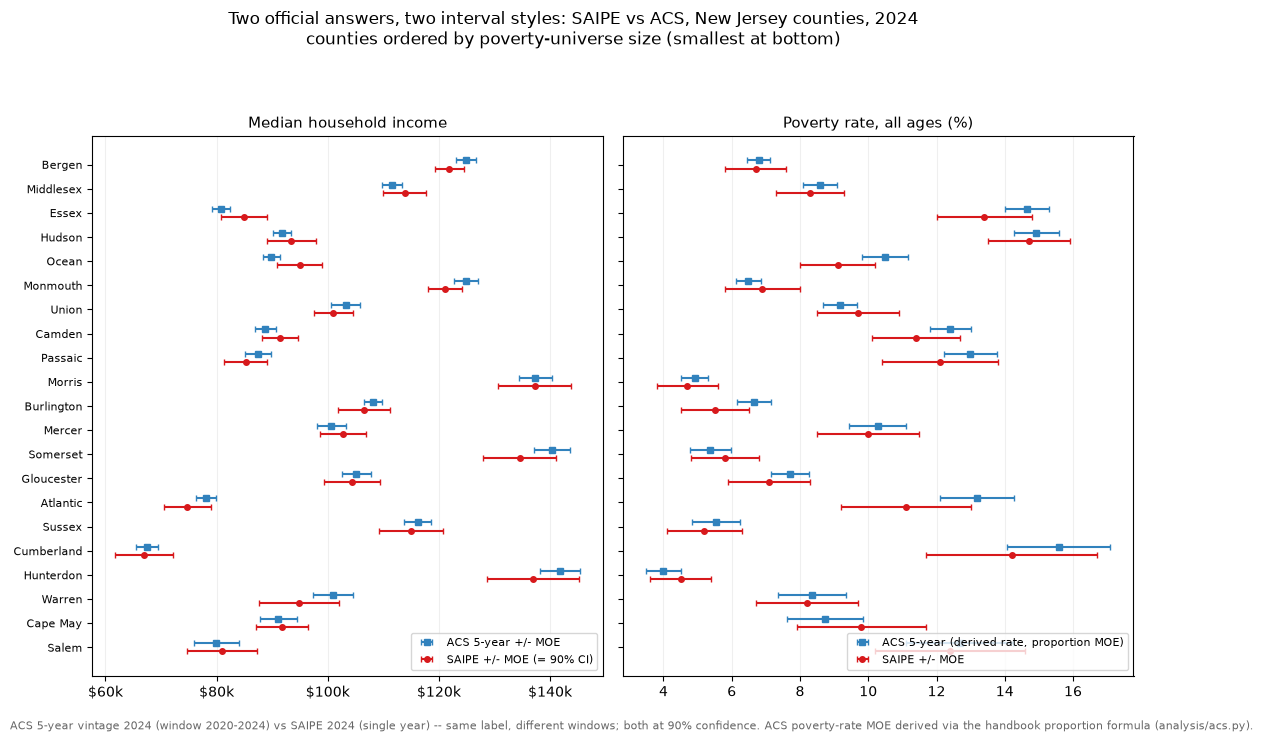

In [8]:
d24 = panel[panel["YEAR"] == "2024"].sort_values("SAEPOVU_ALL").reset_index(drop=True)
y = np.arange(len(d24))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 7.2), sharey=True)

ax = axes[0]
ax.errorbar(d24["B19013_001E"], y + 0.17, xerr=d24["B19013_001M"], fmt="s", color="#3182bd",
            capsize=2.5, markersize=4, label="ACS 5-year +/- MOE")
ax.errorbar(d24["SAEMHI_PT"], y - 0.17, xerr=d24["SAEMHI_MOE"], fmt="o", color="#d7191c",
            capsize=2.5, markersize=4, label="SAIPE +/- MOE (= 90% CI)")
ax.set_yticks(y, d24["short_name"], fontsize=8)
ax.set_title("Median household income", fontsize=11)
ax.xaxis.set_major_formatter(lambda v, _: f"${v/1000:,.0f}k")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
ax.errorbar(d24["pov_rate"], y + 0.17, xerr=d24["pov_rate_moe"], fmt="s", color="#3182bd",
            capsize=2.5, markersize=4, label="ACS 5-year (derived rate, proportion MOE)")
ax.errorbar(d24["SAEPOVRTALL_PT"], y - 0.17, xerr=d24["SAEPOVRTALL_MOE"], fmt="o", color="#d7191c",
            capsize=2.5, markersize=4, label="SAIPE +/- MOE")
ax.set_title("Poverty rate, all ages (%)", fontsize=11)
ax.legend(fontsize=8, loc="lower right")

for ax in axes:
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
fig.suptitle("Two official answers, two interval styles: SAIPE vs ACS, New Jersey counties, 2024\n"
             "counties ordered by poverty-universe size (smallest at bottom)", fontsize=12)
fig.text(0.01, -0.02, "ACS 5-year vintage 2024 (window 2020-2024) vs SAIPE 2024 (single year) -- same label, "
         "different windows; both at 90% confidence. ACS poverty-rate MOE derived via the handbook proportion "
         "formula (analysis/acs.py).", fontsize=8, color="#666666")
fig.tight_layout(rect=(0, 0, 1, 0.93))
out = PROCESSED / "eda10_saipe_vs_acs_intervals.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"Chart saved to {out.relative_to(REPO_ROOT)} (local-only, regenerable)")
plt.show()

**Reading the chart.** Across all 21 counties and both measures, the red (SAIPE) bar is roughly twice the blue (ACS) bar — the 2× headline holds county by county, not just in the median. Both styles widen toward the bottom of the chart (smaller poverty universes), but the ratio between them barely moves. For the pitch: this is the Bureau's *existing* uncertainty communication, shown side by side for the first time in our work — the tool we propose adds the translation layer neither product currently ships.


## Findings

**What did we find?**

1. **The Bureau's two official answers agree on the level and differ on the clock.** Same-label medians sit within ±2% (income) and ±0.5 points (poverty rate), with a time-structured sign flip (SAIPE above the ACS in 17/21 counties in 2019, below it in 18/21 by 2023) that is the single-year-vs-five-year window mismatch made visible.
2. **SAIPE's published interval is ~2× wider than the ACS's, essentially always at NJ county scale** — wider in 99% (income) and 100% (poverty rate) of the 126 county-years; median relative half-widths 4.3% vs 2.2% (income) and 14.8% vs 7.3% (rate); ratio unrelated to county size within NJ (ρ ≈ −0.02). **Narrower is not better:** the ACS buys precision by averaging five years (an older answer), SAIPE buys currency with width. The two intervals price different questions.
3. **Containment is asymmetric in exactly the way the widths predict:** ACS points fall inside SAIPE's CI 75–86% of the time; SAIPE points fall inside the ACS's narrower interval only 51–61% of the time.
4. **Four honest presentations of one number carry four different messages** (Section 6) — only the CV-plus-tier form is actionable without statistical training, which is the dashboard's brief.

**Why it matters to the Census Bureau.** The Bureau already publishes income and poverty two ways with two uncertainty styles, and neither is "the" answer — the tighter interval answers an older question, the wider one a current question. A reliability tool therefore shouldn't rank products; it should *translate* — state what question each number answers and how sure it is on its own terms, with tier language that is product-aware. SAIPE also stands as thirty years of proof that publishing intervals with every estimate is operationally workable — the precedent our proposal extends to the neighborhood-level ACS, where the uncertainty is largest and least visible.

**What should we do next?**

- Both charts go to the concept pitch (`eda10_saipe_vs_acs_intervals.png` flagship; `eda10_window_mismatch.png` as the window-mismatch teaching slide), alongside the Section 6 four-presentations exhibit.
- The tool's verdict copy becomes **product-aware**: ACS tier text should carry the "five-year average centered ~2 years back" caveat; any SAIPE reference the "single-year, model-based" one.
- Post-merge, extend the comparison nationally with Garrett's all-US pull scripts — the prediction to test: SAIPE's width disadvantage should shrink or reverse in small counties, where direct ACS estimates fall apart. Stating that prediction in the pitch makes the national extension a designed experiment, not a fishing trip.
- EDA 11 (tier stability across vintages 2023↔2024) is the remaining pre-MVP analysis.

*Charts saved: `eda10_saipe_vs_acs_intervals.png`, `eda10_window_mismatch.png` (local-only, regenerable by this notebook).*
